# Experiment 8 Analysis: VC Repair Algorithms Comparison
Goal: Compare Vanilla VC, Classic VC, and Weighted VC (Adaptive Alpha) as a function of epsilon.
#
## Missing Data: Tax Dataset
The **Tax** dataset is missing from these results. Investigation shows that the `tax` dataset contains **range constraints** (e.g., `t1.Salary > t2.Salary & t1.Rate < t2.Rate`).
At the requested sample size of **300,000**, these constraints trigger a "Quadratic Trap" in violation detection, generating billions of edges in the conflict graph. 
These jobs likely timed out or hit memory limits (64GB+) on the cluster and did not produce results.


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Find project root
cwd = Path.cwd()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent.parent
else:
    PROJECT_ROOT = cwd

# Add project root to sys.path for imports
sys.path.append(str(PROJECT_ROOT))
from s06_analysis.src.io.result_flattener import ResultFlattener

# Configure seaborn styling
sns.set_theme(style="whitegrid", context="talk")

# Define fixed colors and widths for overlapping bars
REPAIR_CONFIG = {
    "classic_vc":  {"color": "#e74c3c", "width": 0.32, "label": "Classic VC", "zorder": 1},
    "vanilla_vc":  {"color": "#3498db", "width": 0.22, "label": "Vanilla VC", "zorder": 2},
    "weighted_vc": {"color": "#2ecc71", "width": 0.12, "label": "Weighted VC", "zorder": 3}
}

SYNTH_OFFSETS = {
    "aim": -0.18,
    "mst": 0.18
}

# Load data
DATA_PATH = PROJECT_ROOT / "s06_analysis/input/experiment_8_results.csv"
raw_df = pd.read_csv(DATA_PATH)
flattener = ResultFlattener()
df, topology_df = flattener.flatten(raw_df)

print(f"Loaded {len(df)} records.")
datasets = sorted(df['dataset'].unique())
eps_vals = sorted(df['epsilon'].unique())
repair_algos = ["classic_vc", "vanilla_vc", "weighted_vc"]
synths = ["aim", "mst"]

metrics = [
    ('deletion_ratio', 'Deletion Ratio'),
    ('marginals_error_repaired', 'Marginals Error'),
    ('loss_marginal_repaired', 'Marginals Loss'),
    ('tvd_repaired', 'Total Variation Distance (TVD)'),
    ('ml_acc_repaired', 'ML Accuracy'),
    ('repair_runtime', 'Runtime (seconds)')
]


Loaded 1200 records.


## Nested Bar Graph Analysis (Full Width - Log Scale)
Each metric is plotted in its own figure.
- **Reference Lines**: Dashed lines represent the performance of the **Original Synthetic Data** (before repair).
- **Log Scale**: Applied to metrics with high dynamic range.


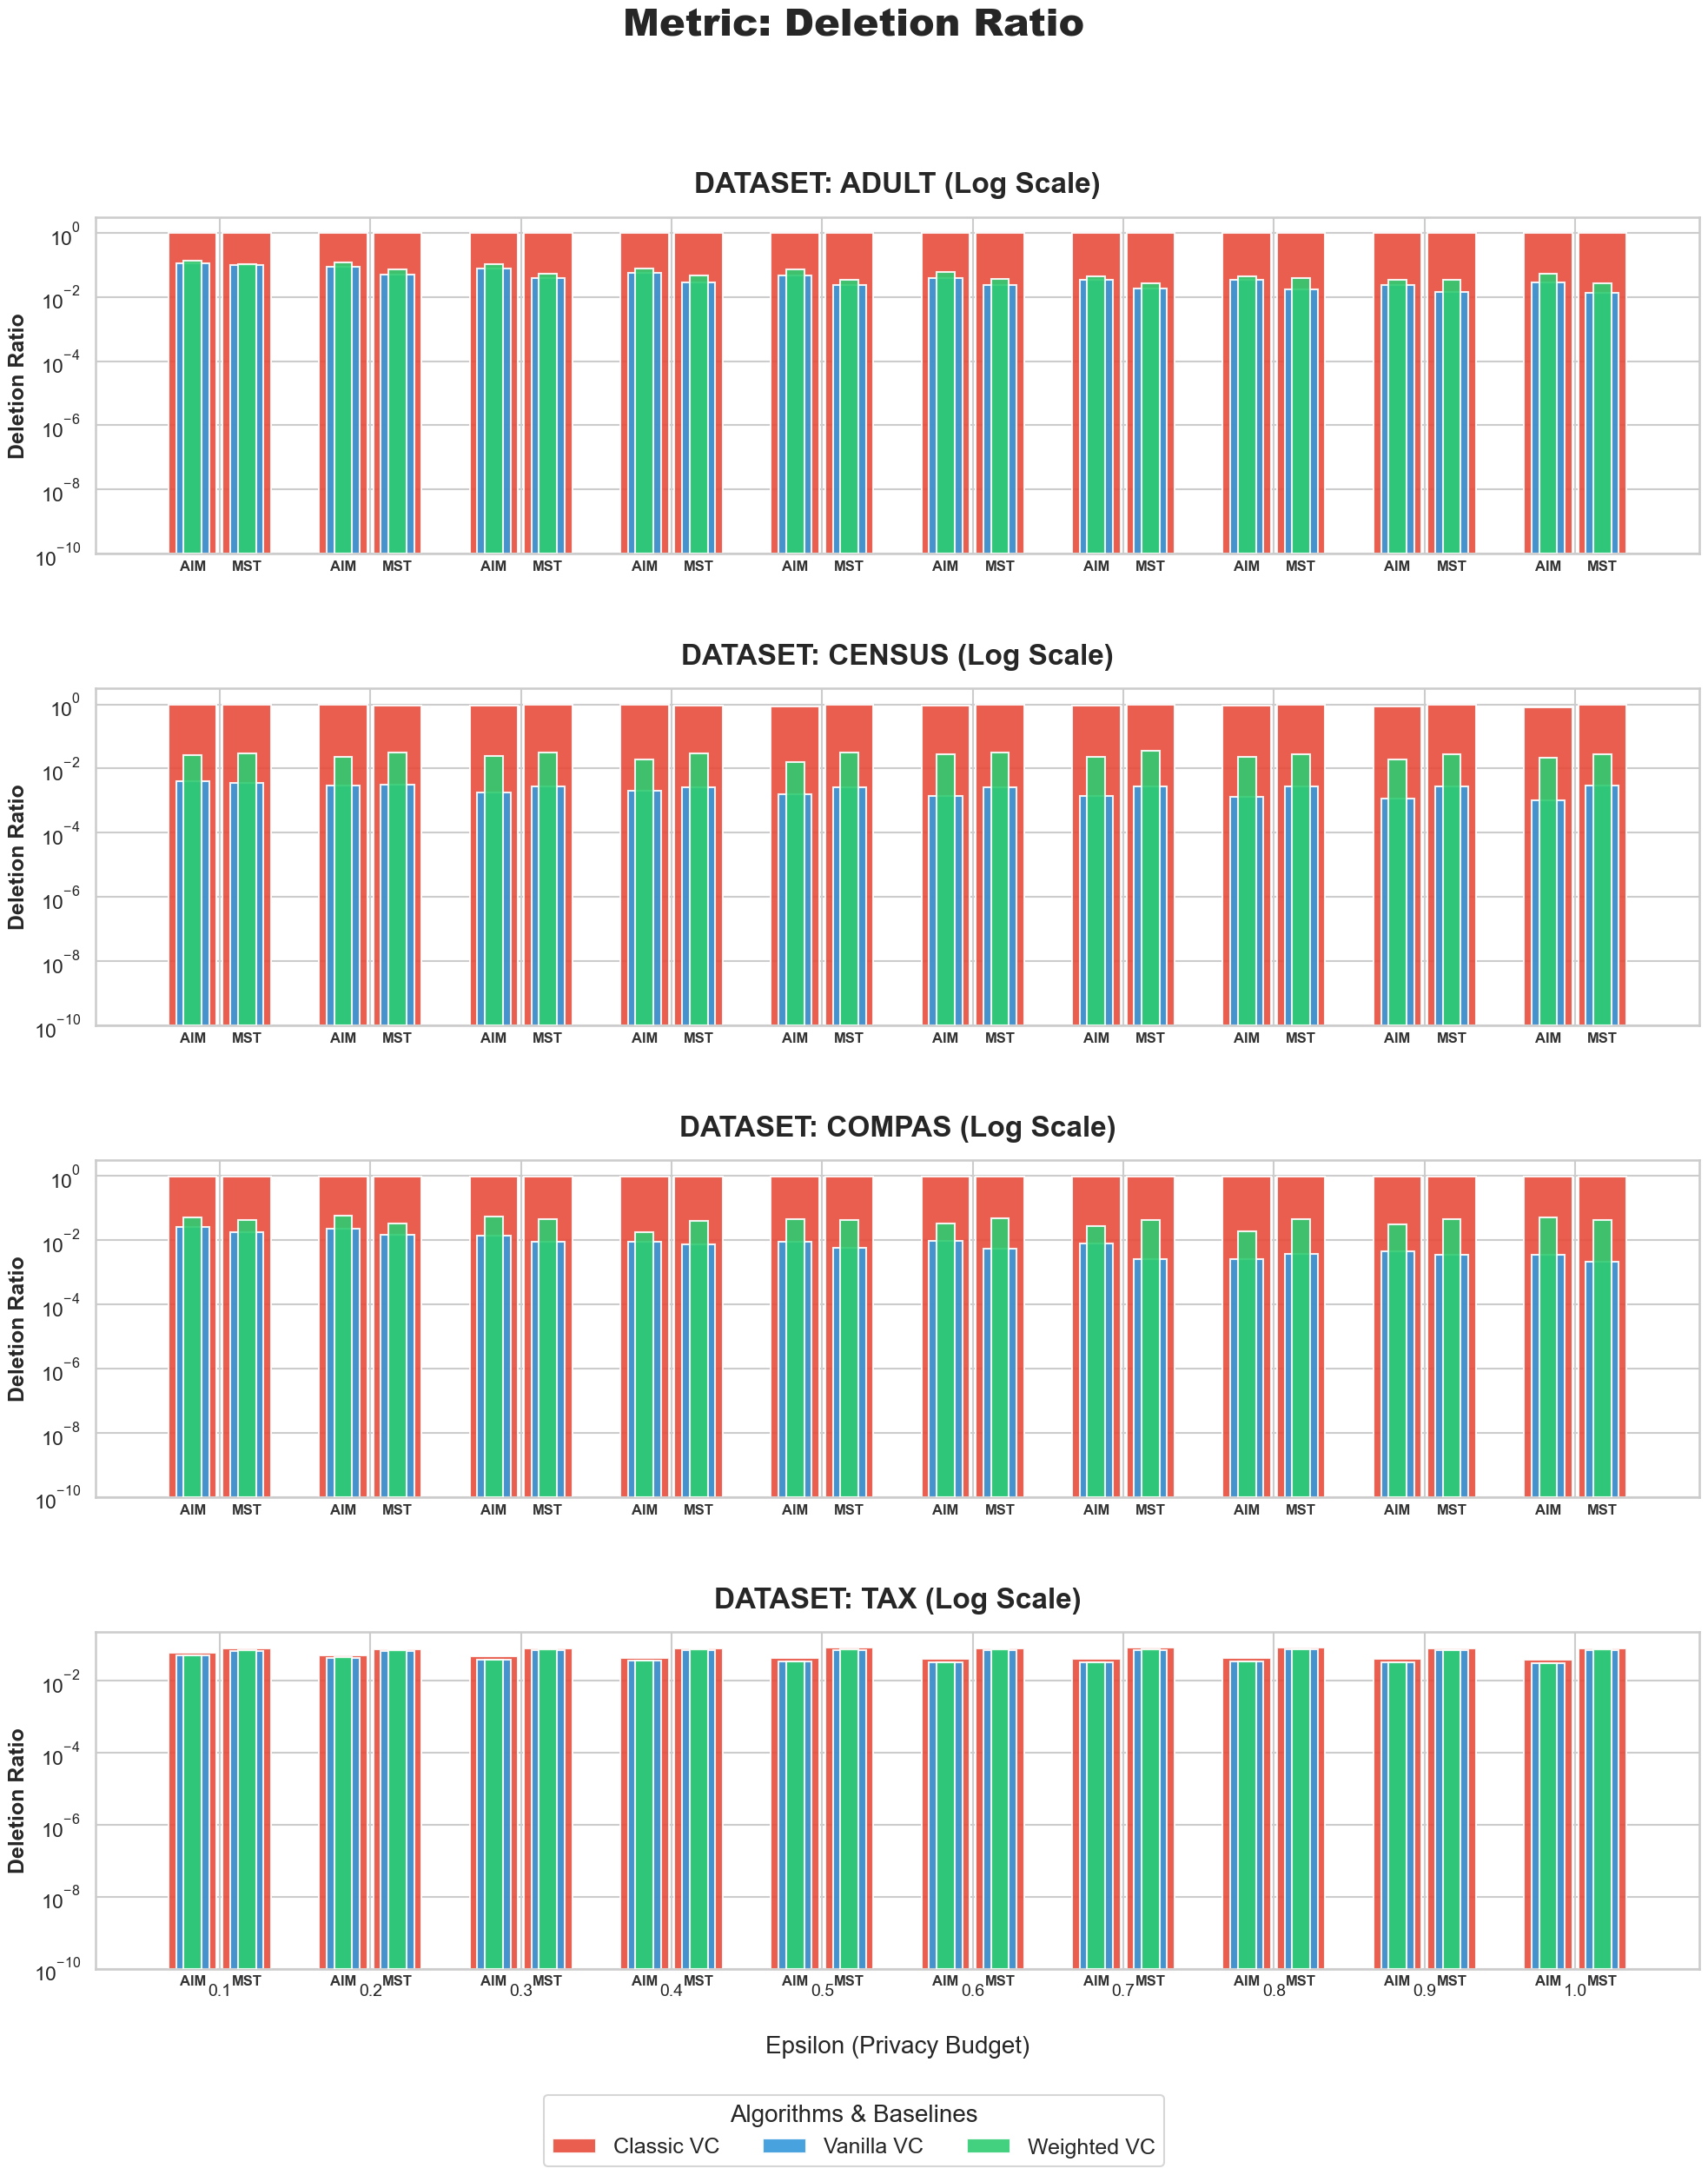

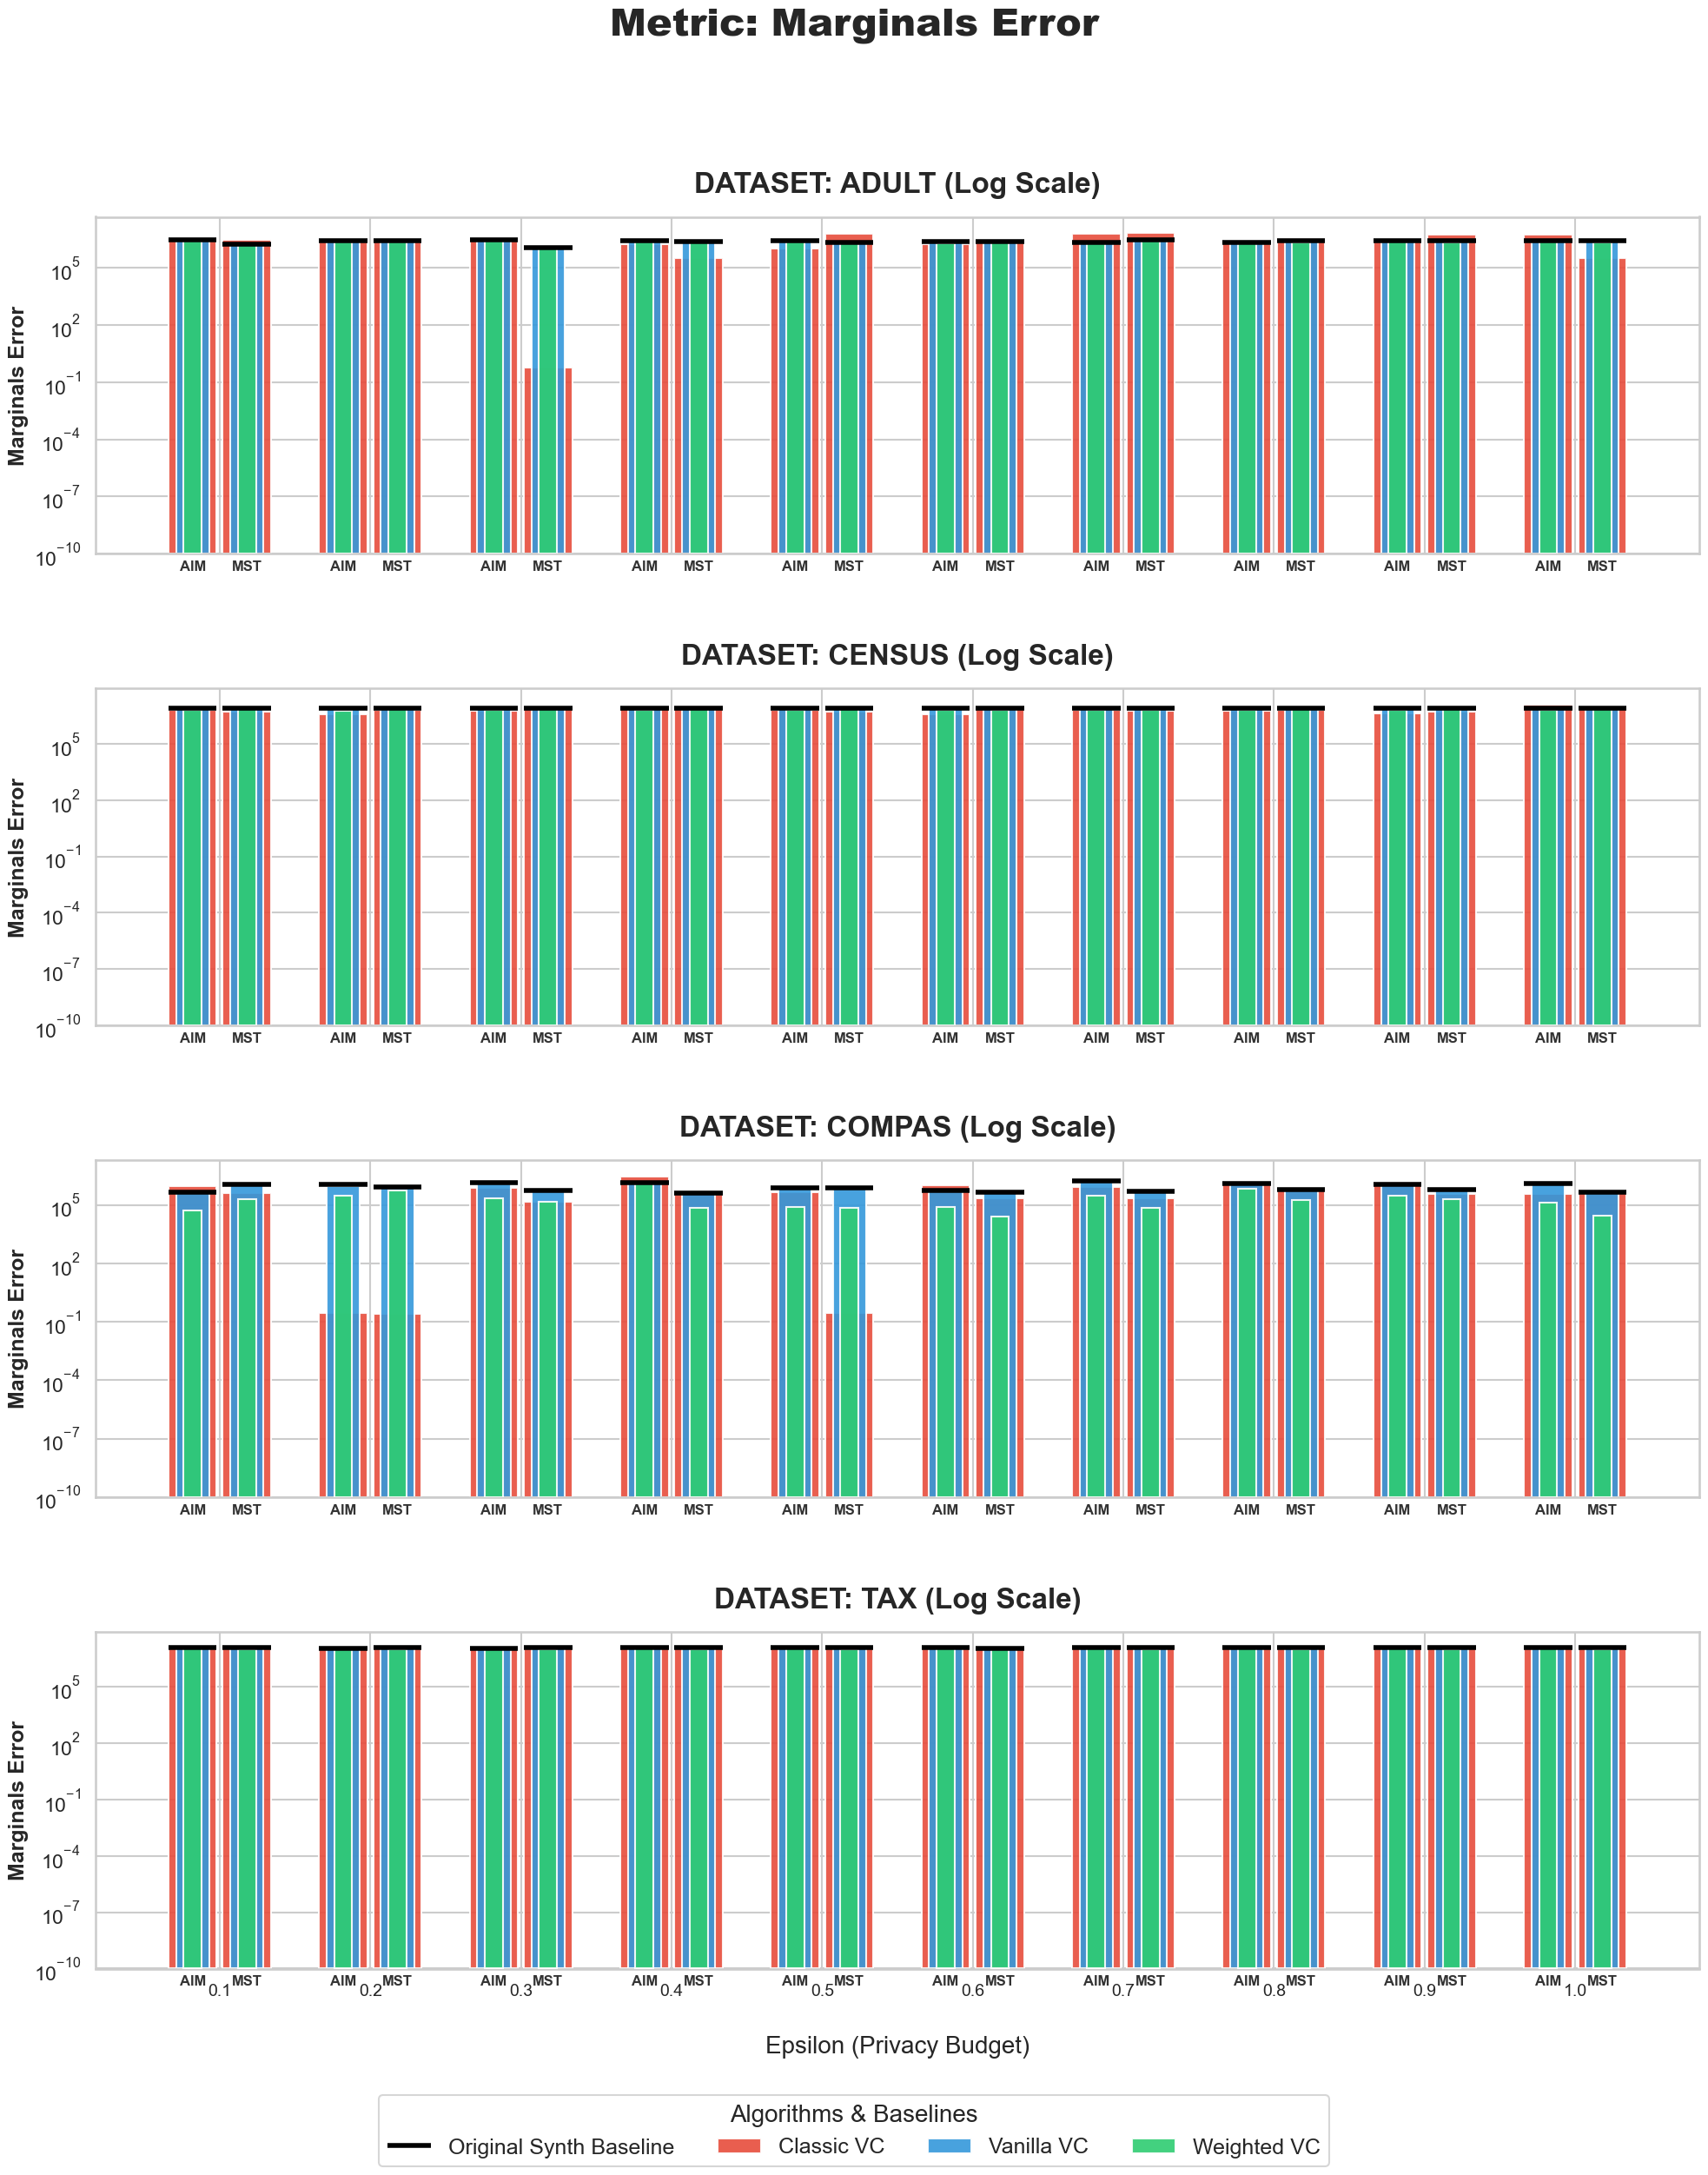

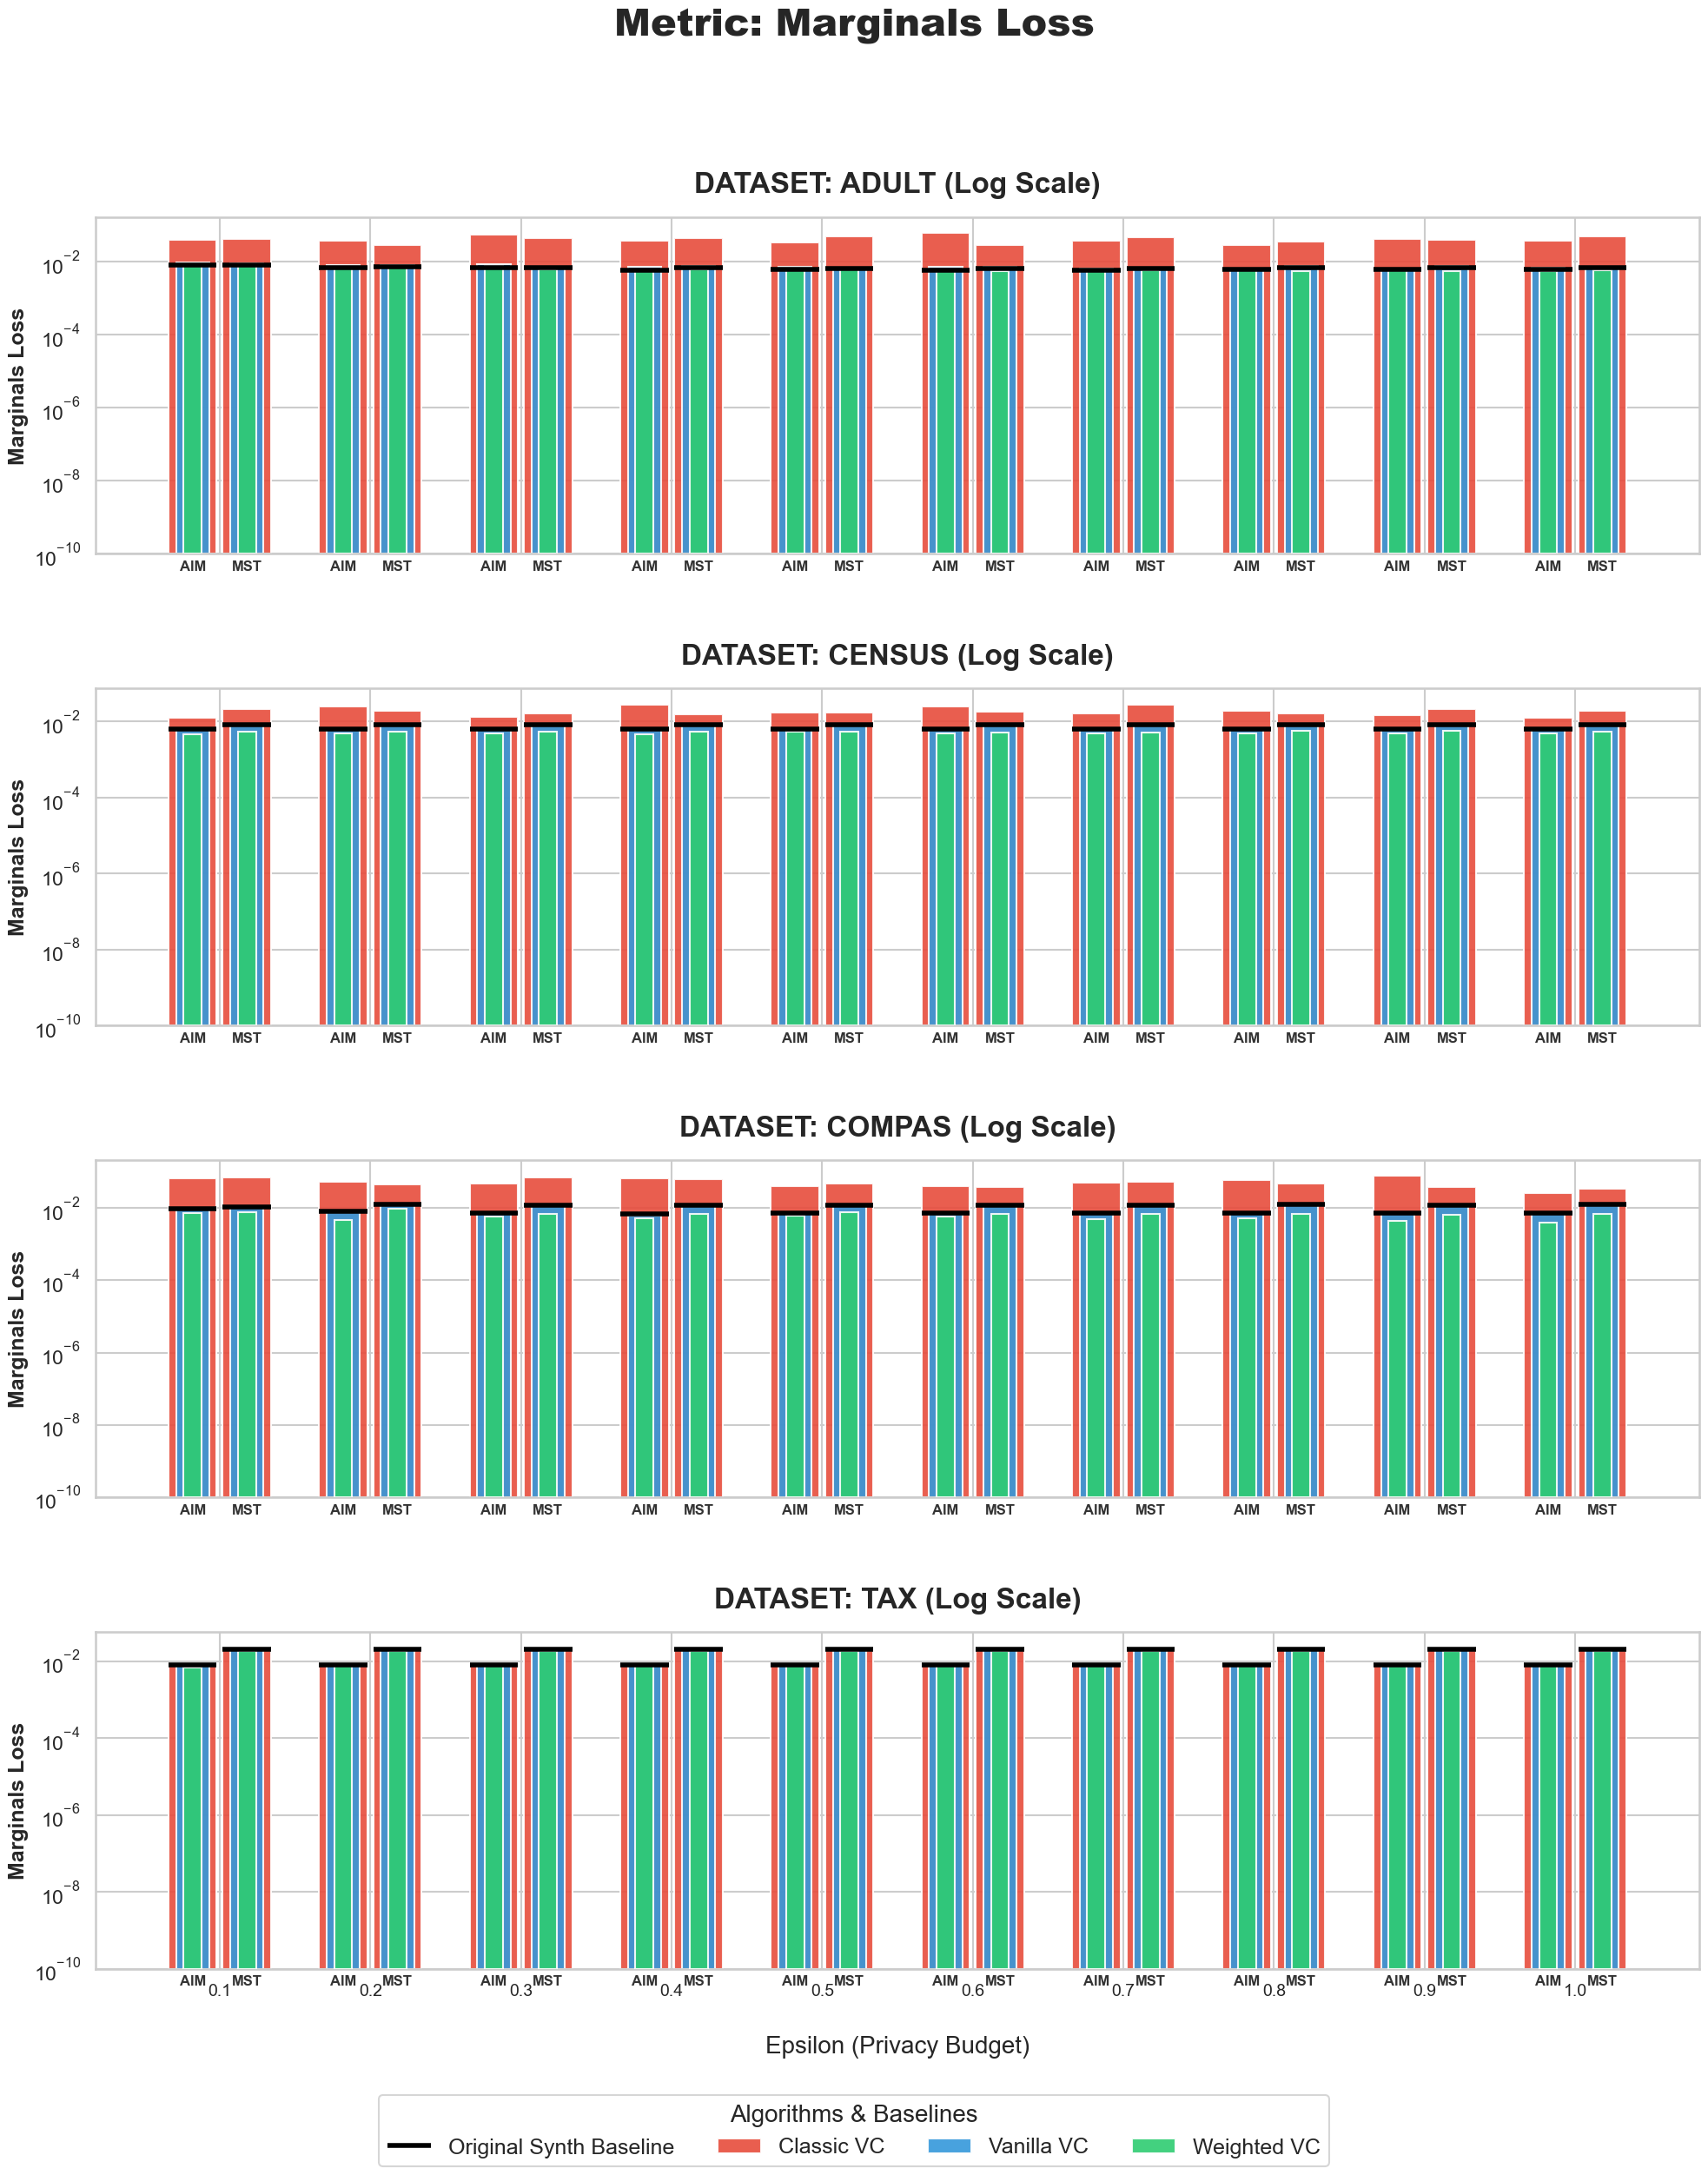

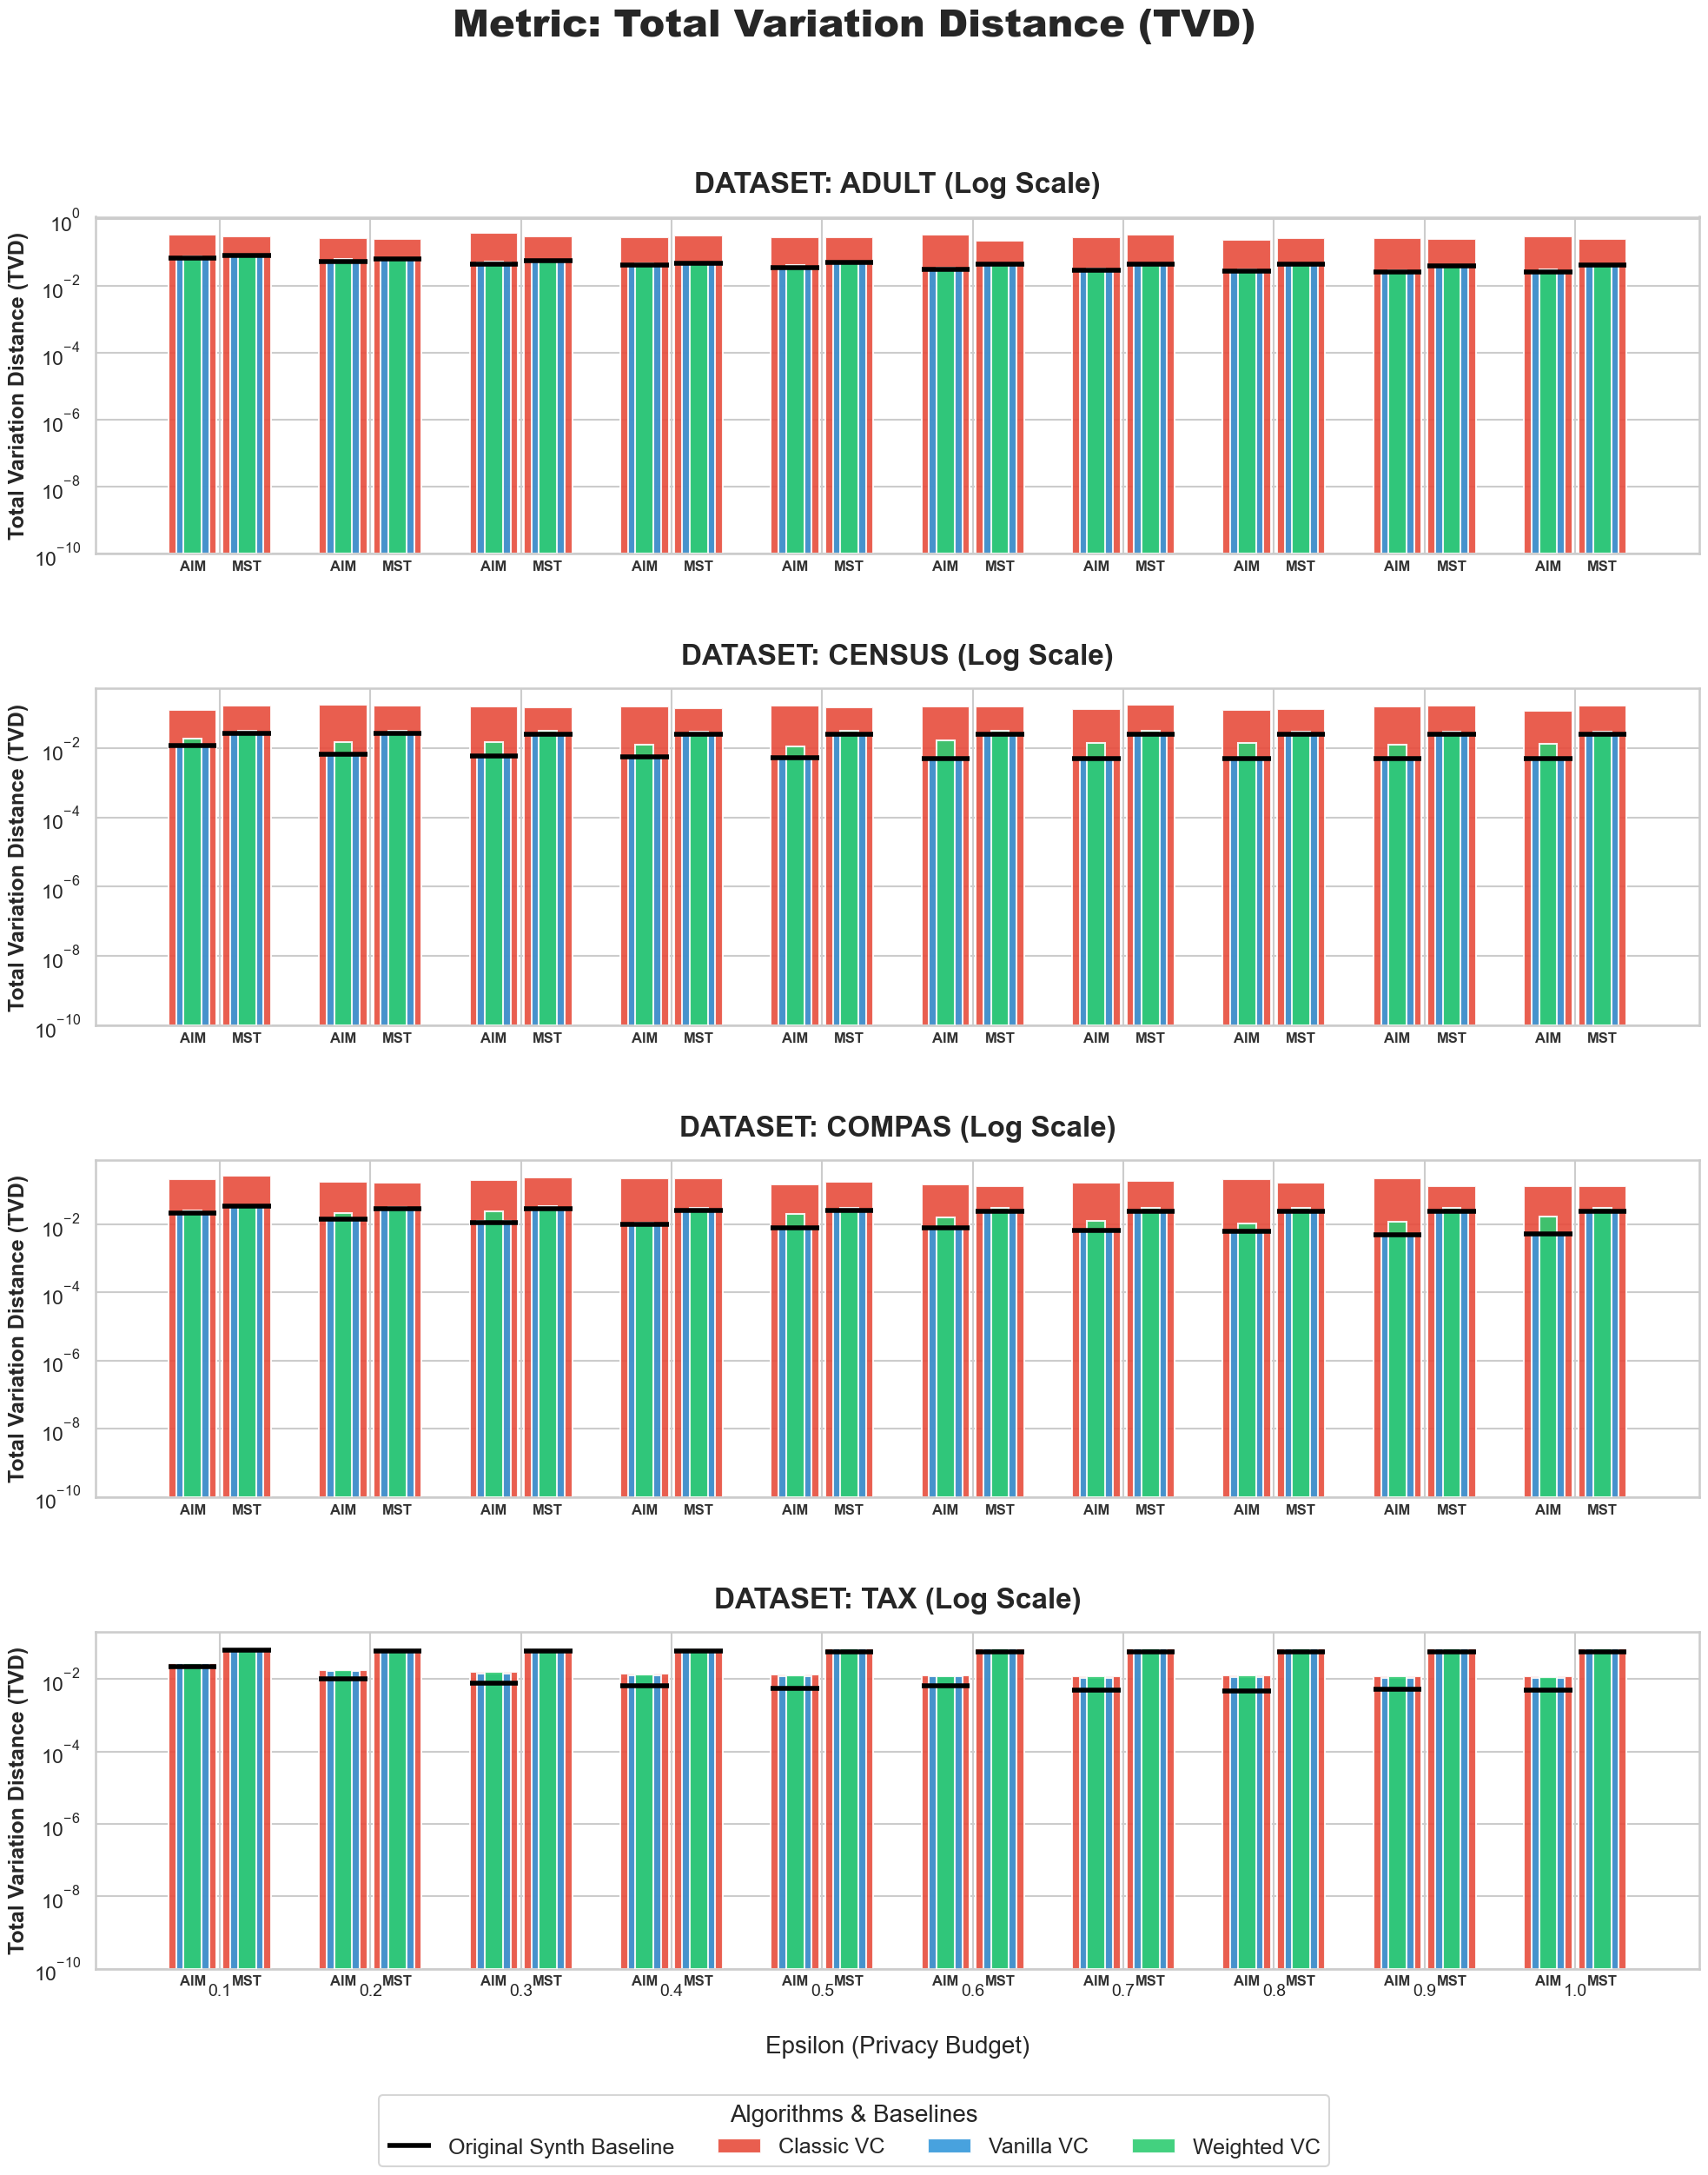

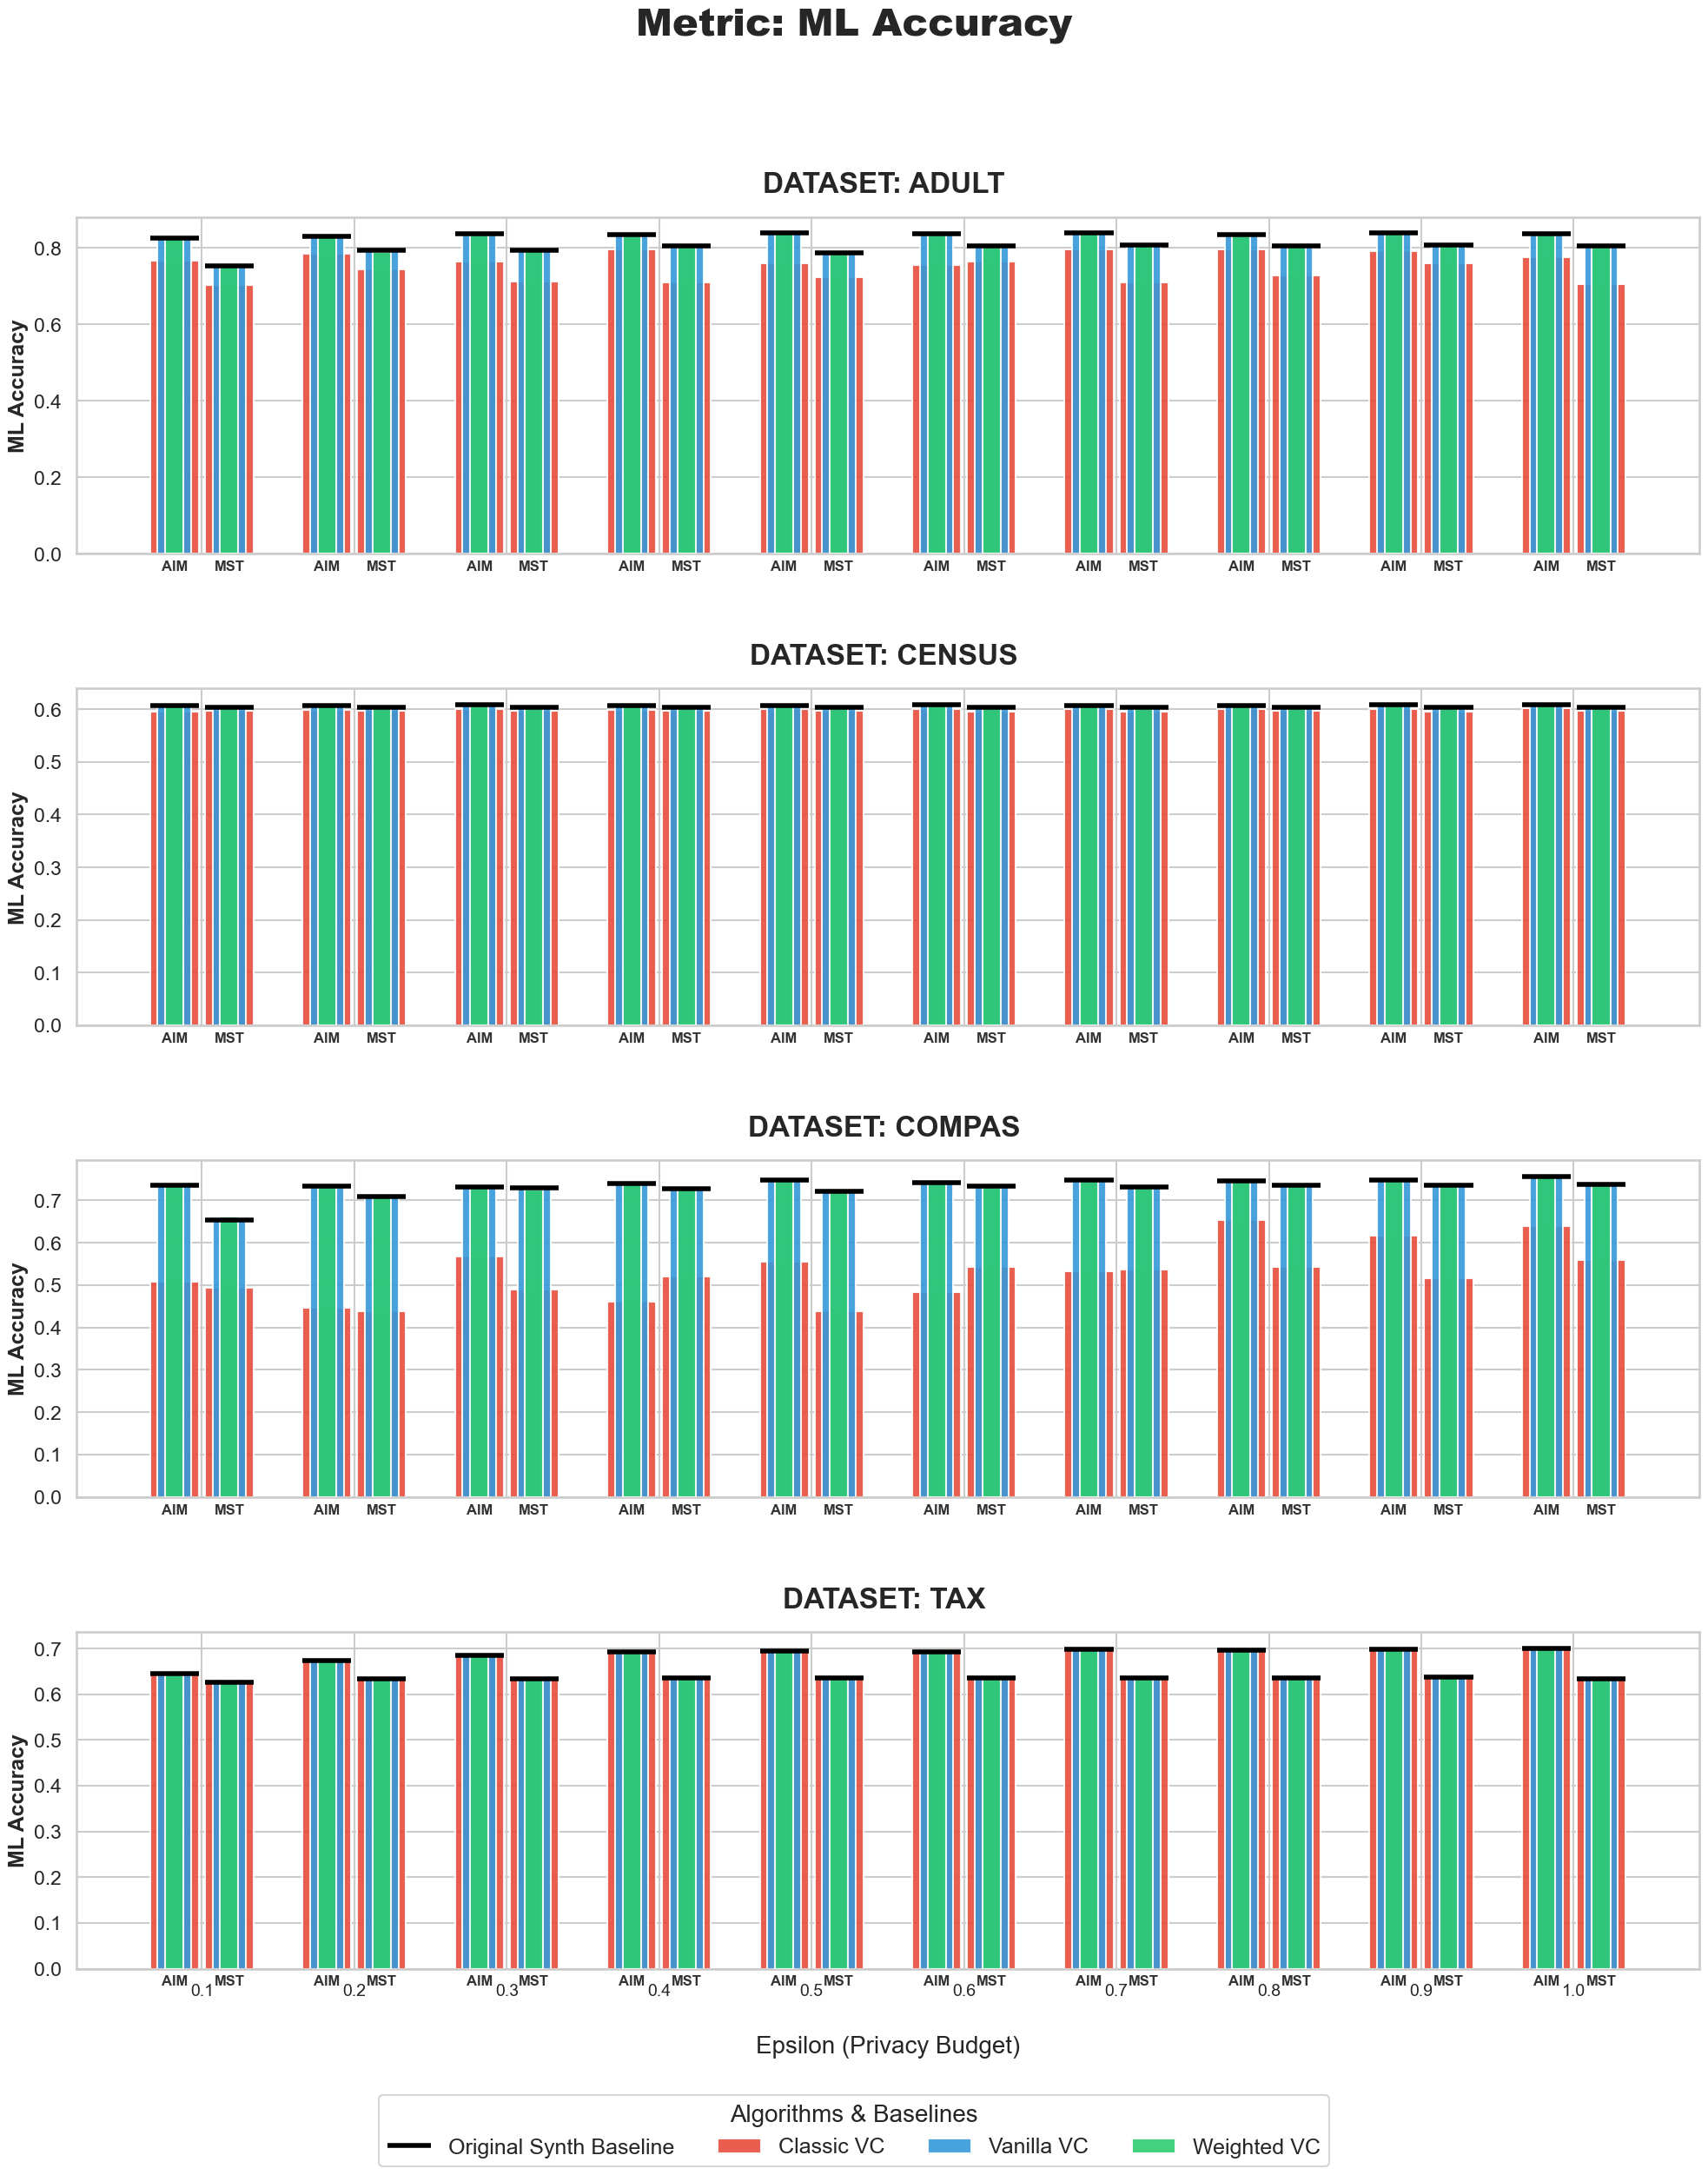

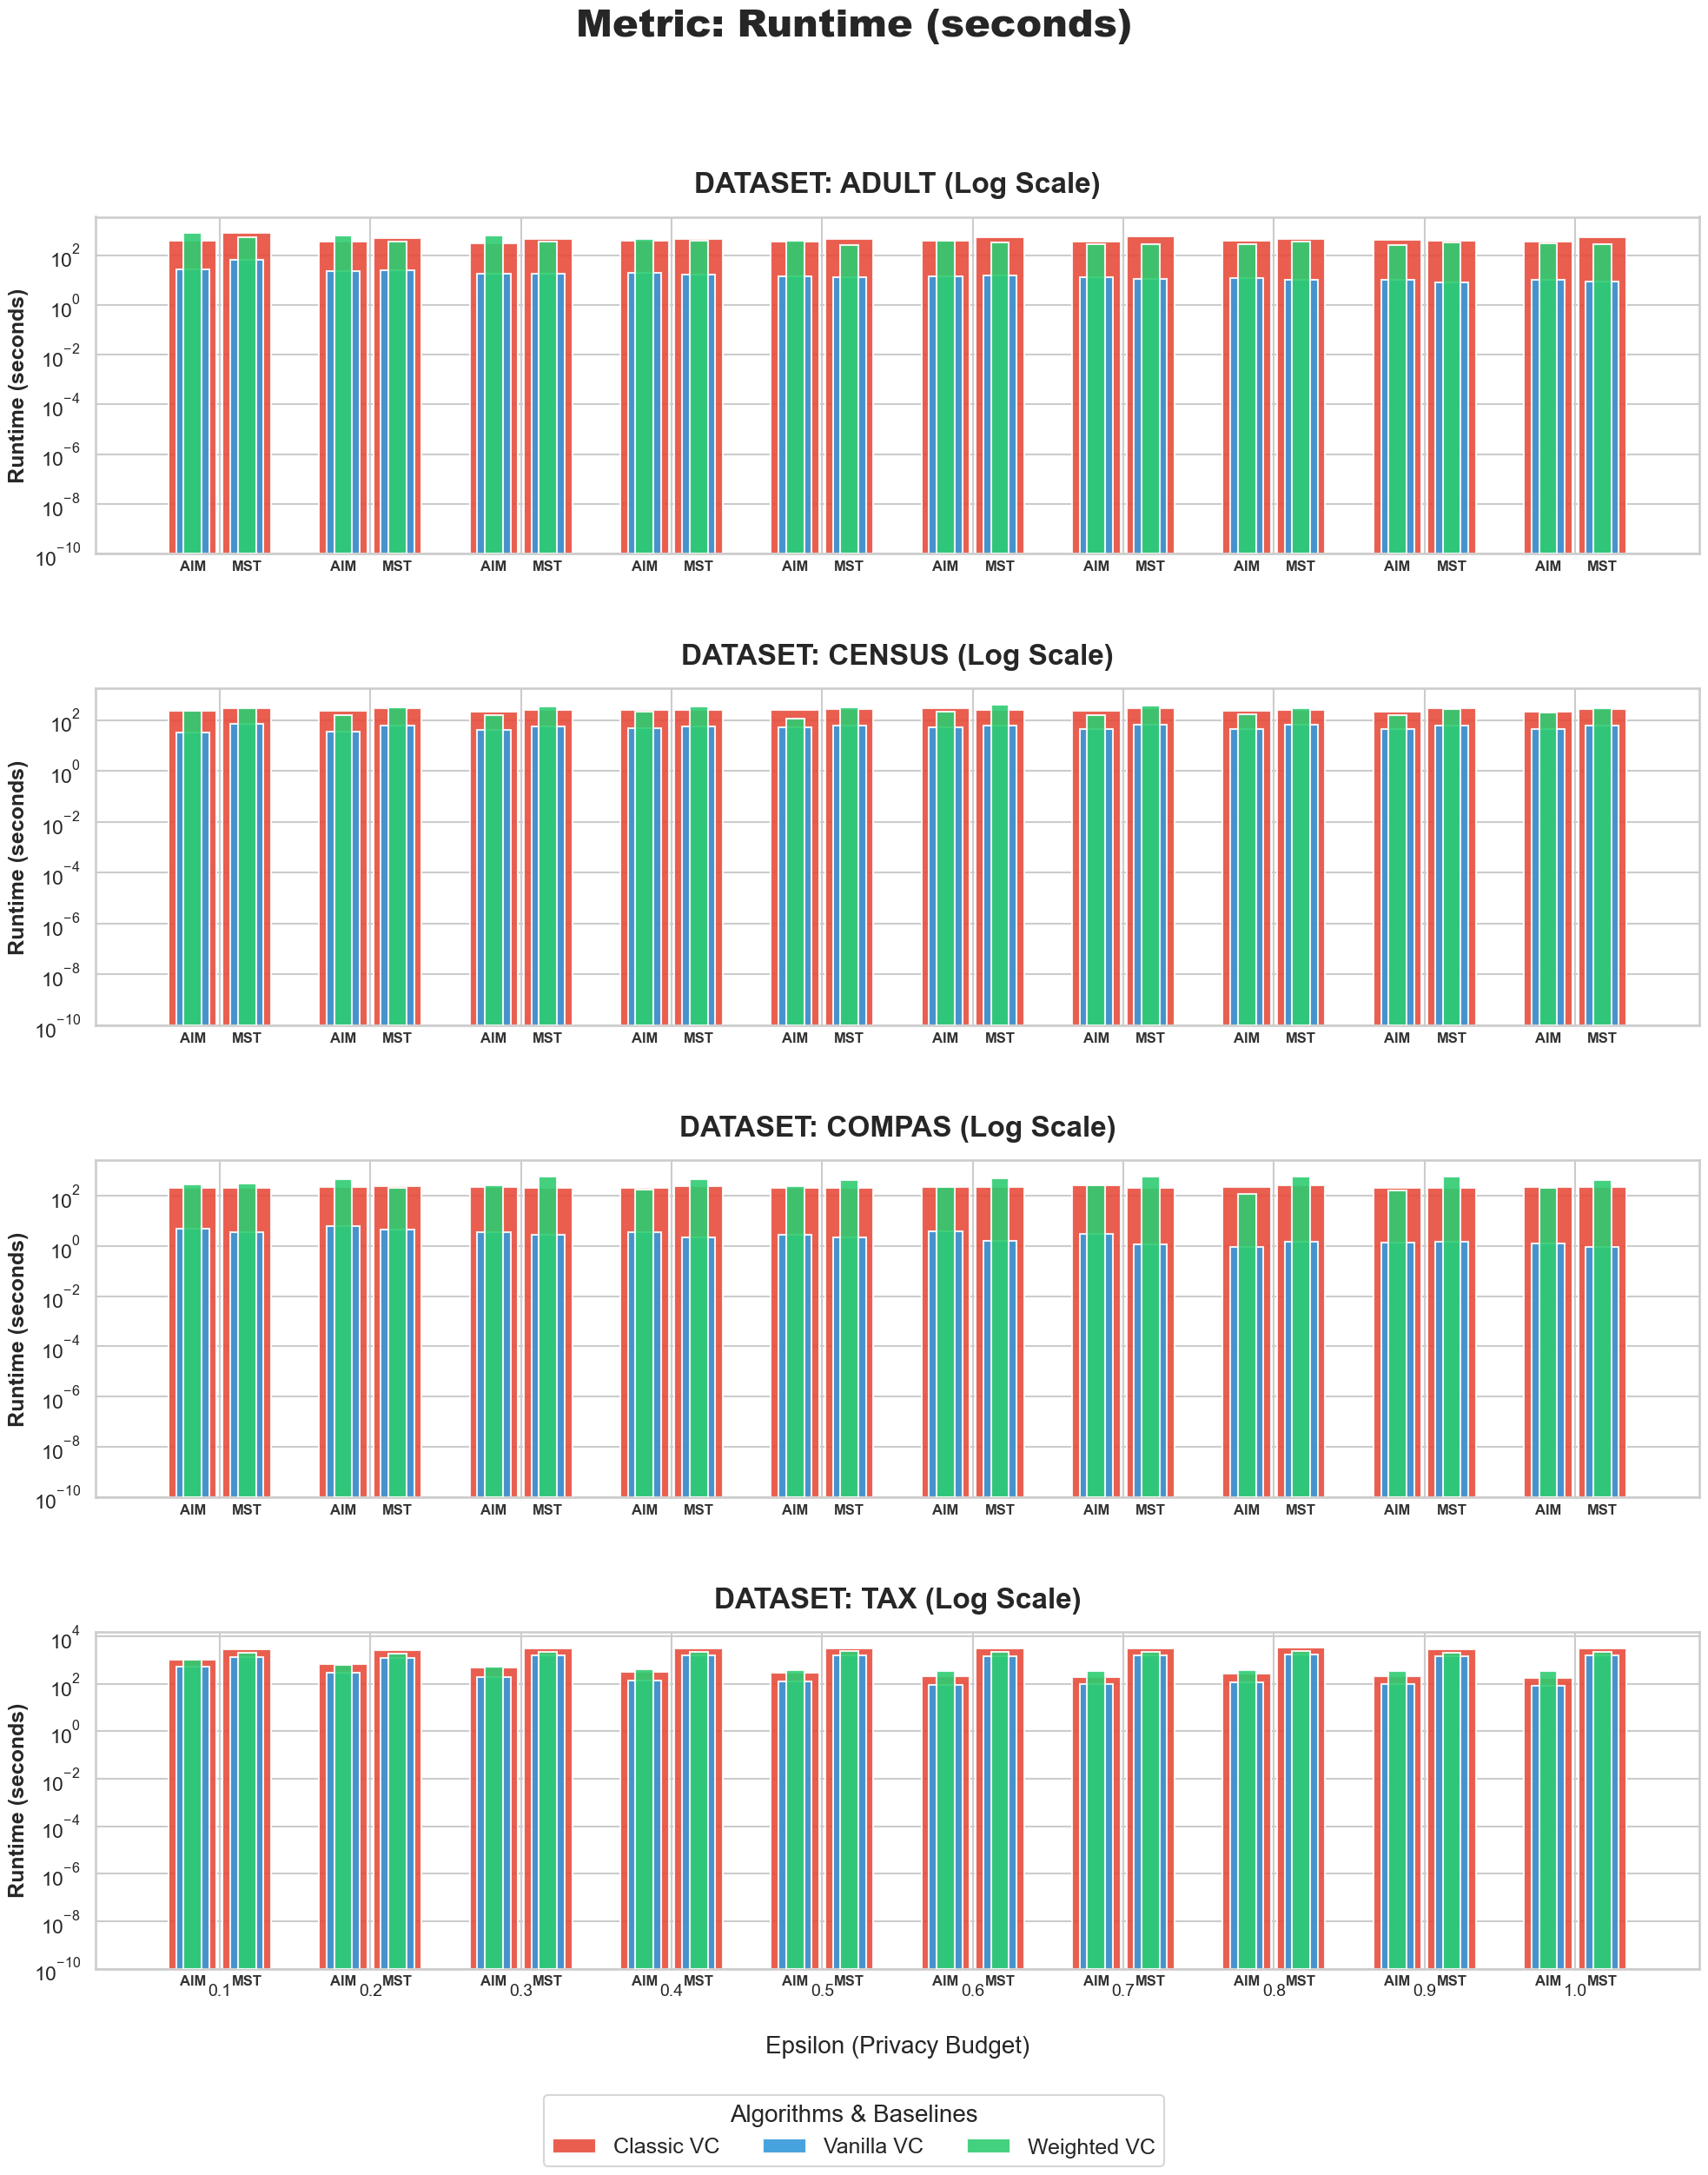

In [46]:
LOG_METRICS = ['marginals_error_repaired', 'tvd_repaired', 'repair_runtime', 'deletion_ratio', 'loss_marginal_repaired']

for metric_id, metric_name in metrics:
    use_log = metric_id in LOG_METRICS
    fig, axes = plt.subplots(len(datasets), 1, figsize=(20, 24), sharex=True)
    
    # Map metrics to their synthetic baseline equivalents
    synth_metric_map = {
        'marginals_error_repaired': 'marginals_error_synthetic',
        'loss_marginal_repaired': 'loss_marginal_synthetic',
        'tvd_repaired': 'tvd_synthetic',
        'ml_acc_repaired': 'ml_acc_synthetic'
    }
    synth_metric_id = synth_metric_map.get(metric_id)

    for d_idx, ds in enumerate(datasets):
        ax = axes[d_idx]
        ds_df = df[df['dataset'] == ds]
        
        x_indices = np.arange(len(eps_vals))
        
        for s_idx, synth in enumerate(synths):
            offset = SYNTH_OFFSETS[synth]
            
            # 1. Plot Synthetic Baseline (Horizontal Segment)
            if synth_metric_id and synth_metric_id in ds_df.columns:
                subset_synth = ds_df[ds_df['synthesizer'] == synth]
                # Group by epsilon to get mean baseline
                baseline_vals = [subset_synth[subset_synth['epsilon'] == ev][synth_metric_id].mean() for ev in eps_vals]
                
                # Calculate horizontal bounds for the baseline marker
                group_width = REPAIR_CONFIG["classic_vc"]["width"]
                x_starts = x_indices + offset - group_width / 2
                x_ends = x_indices + offset + group_width / 2
                
                ax.hlines(baseline_vals, x_starts, x_ends, colors='black', linewidth=4, 
                          label="Original Synth Baseline" if (d_idx == 0 and s_idx == 0) else "",
                          zorder=5) # Ensure it's on top of bars

            # 2. Plot Repair Bars (Nested)

            for algo in repair_algos:
                cfg = REPAIR_CONFIG[algo]
                subset = ds_df[(ds_df['synthesizer'] == synth) & (ds_df['repair_algorithm'] == algo)]
                
                vals = []
                for ev in eps_vals:
                    row = subset[subset['epsilon'] == ev]
                    vals.append(row[metric_id].mean() if not row.empty else 0)
                
                ax.bar(
                    x_indices + offset, 
                    vals, 
                    width=cfg['width'], 
                    color=cfg['color'], 
                    label=cfg['label'] if (d_idx == 0 and s_idx == 0) else "",
                    zorder=cfg['zorder'],
                    alpha=0.9,
                    bottom=1e-10 if use_log else 0
                )
        
        if use_log:
            ax.set_yscale('log')
            
        ax.set_title(f"DATASET: {ds.upper()} {'(Log Scale)' if use_log else ''}", fontsize=24, fontweight='bold', pad=20)
        ax.set_xticks(x_indices)
        ax.set_xticklabels(eps_vals, rotation=0, fontsize=14)
        ax.set_ylabel(metric_name, fontsize=18, fontweight='bold')
        
        # Consistent label positioning using axes transform (fractional coordinates)
        # 0.0 is bottom of plot area, 1.0 is top.
        for xi in x_indices:
            ax.text(xi + SYNTH_OFFSETS['aim'], -0.05, 'AIM', transform=ax.get_xaxis_transform(), 
                    ha='center', fontsize=12, color='#333333', fontweight='bold')
            ax.text(xi + SYNTH_OFFSETS['mst'], -0.05, 'MST', transform=ax.get_xaxis_transform(), 
                    ha='center', fontsize=12, color='#333333', fontweight='bold')

    axes[-1].set_xlabel("Epsilon (Privacy Budget)", fontsize=20, labelpad=30)
    
    # Place legend at the bottom to avoid overlapping with titles
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), 
               ncol=4, fontsize=18, title="Algorithms & Baselines", title_fontsize=20)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.4, bottom=0.08)
    fig.suptitle(f"Metric: {metric_name}", fontsize=32, y=1.02, fontweight='black')
    plt.show()
